<a href="https://colab.research.google.com/github/flintop123/automatic-funicular/blob/main/HuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers
!pip install datasets

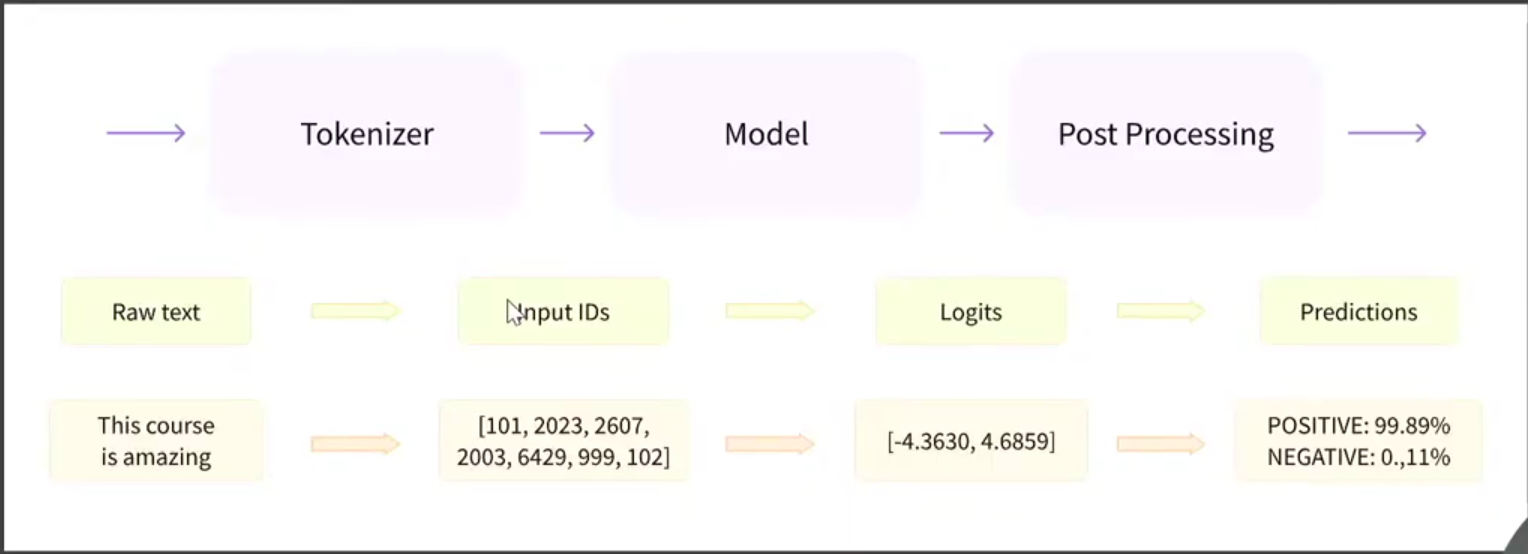

In [ ]:
from collections import defaultdict, Counter
import json

from matplotlib import pyplot as plt
import numpy as np
import torch

def print_encoding(model_inputs, indent=4):
  indent_str = ""+indent
  print("{")
  for k,v in model_inputs.items():
    print(indent_str + k + ":")
    print(indent_str + indent_str + str(v))
  print("}")

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("siebert/sentiment-roberta-large-english")
model = AutoModelForSequenceClassification.from_pretrained("siebert/sentiment-roberta-large-english", device_map="auto")

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.42GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
inputs = "I'm excited to learn about Transformers!"
tokenized_inputs = tokenizer(inputs, return_tensors="pt")
outputs = model(**tokenized_inputs)

In [ ]:
labels = ['NEGATIVE', 'POSITVE']
prediction = torch.argmax(outputs.logits)

In [ ]:
torch.softmax(outputs.logits, dim=1)

tensor([[0.0012, 0.9988]], grad_fn=<SoftmaxBackward0>)

In [ ]:
print(f"Input : {inputs}\n")
print(f"Tokenized Inputs : {tokenized_inputs}\n")
print("MOdel Outputs:")
print(outputs)
print(f"The prediction is {labels[prediction]}")

Input : I'm excited to learn about Transformers!

Tokenized Inputs : {'input_ids': tensor([[    0,   100,   437,  2283,     7,  1532,    59, 34379,   328,     2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

MOdel Outputs:
SequenceClassifierOutput(loss=None, logits=tensor([[-3.7800,  2.9480]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
The prediction is POSITVE


# **Tokenizers**

In [ ]:
from transformers import DistilBertTokenizer, DistilBertTokenizerFast, AutoTokenizer
name = "distilbert/distilbert-base-cased"
tokenizer = DistilBertTokenizer.from_pretrained(name)
print(tokenizer)

tokenizer = AutoTokenizer.from_pretrained(name) #conveninet
print(tokenizer)

DistilBertTokenizer(name_or_path='distilbert/distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

BertTokenizer(name_or_path='distilbert/distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [ ]:
#call the tokenizer
input_str = "NPTEL is great"
tokenized_inputs= tokenizer(input_str, return_tensors="pt") #if we remove return_tensors="pt" then it will return list of tokens

In [ ]:
print(tokenized_inputs)

{'input_ids': tensor([[  101,   151,  2101, 12880,  2162,  1110,  1632,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}


In [ ]:
print(tokenized_inputs.input_ids)
print(tokenized_inputs["input_ids"])

tensor([[  101,   151,  2101, 12880,  2162,  1110,  1632,   102]])
tensor([[  101,   151,  2101, 12880,  2162,  1110,  1632,   102]])
